## Comment utiliser ce notebook
Cliquer sur une cellule et presser Entrée pour éditer une cellule.<br/>
Appuyer sur Shift+Entrée pour exécuter la cellule.<br/>
Pour répondre à un exercice, remplacer la ligne
```python
# <- completer ici
```
par votre code et exécuter la cellule.
<hr/>

### Vectorisation

Sous-sections :
[Broadcasting](#broadcasting)&nbsp;|
[Vectorisation](#vectorisation)&nbsp;|
[Exercices](#exercices)&nbsp;


NumPy tire partie de sa stratégie de stockage des tableaux
dans des blocs mémoire contigüs de taille fixe pour optimiser les
traitements.

<a id="broadcasting"></a>
##### Broadcasting

NumPy peut faire des opérations sur des tableaux qui n'ont pas la même géométrie (*shape*), comme ici :
![broadcast example](../images/broadcasting_1.png)

In [78]:
import numpy as np

a = np.array([1, 2, 3])  # shape (3,)
b = np.array([2])  # shape (1,)

In [ ]:
a * b  # ou simplement a * 2, on multiplie par 2 à chaque élément du tableau a

array([2, 4, 6])

On peut utiliser cette technique par exemple 
pour calculer les différences entre une nouvelle entrée __x__ et chacune des entrées __xi__ de la base de cas :

In [80]:
import numpy as np
X = np.array(
    [
        (2, -5),
        (8, -4),
        (-17, -23),
        (28, 0),
        (-8, -7),
        (3, 2.9),
        (23, 14),
        (7, 14),
        (-2, 28),
    ]
)
x = np.array((0, 3))

x - X

array([[ -2. ,   8. ],
       [ -8. ,   7. ],
       [ 17. ,  26. ],
       [-28. ,   3. ],
       [  8. ,  10. ],
       [ -3. ,   0.1],
       [-23. , -11. ],
       [ -7. , -11. ],
       [  2. , -25. ]])

Pour que cette technique de [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) puisse être appliquée, NumPy impose que dans chaque dimension, les deux tableaux contiennent :
- soit le même nombre d'éléments
- soit 1 seul élément

NumPy fabrique alors des tableaux de même géométrie en dupliquant les valeurs lorsqu'une dimension ne contient qu'un élément,
puis, une fois qu'il a des tableaux de même géométrie,
applique l'opération sur les éléments 2 à 2.

Par exemple, on peut multiplier (opération `*`) un tableau de géométrie (1,3) avec un tableau de géométrie (2,1), et le résultat sera un tableau de géométrie (2,3).



In [81]:
a = np.array([1, 2, 3])  # shape (3,)
b = np.array([[3], [7]])  # shape (2,1)
a * b

array([[ 3,  6,  9],
       [ 7, 14, 21]])

car les tableaux `a` et `b` sont étendus de la manière suivante :

In [82]:
a = np.array([1, 2, 3])  # shape (3,)
a = np.array([[1, 2, 3]])  # -> extended to shape (1,3)
a = np.array([[1, 2, 3], [1, 2, 3]])  # -> extended to shape (2,3)

b = np.array([[3], [7]])  # shape (2,1)
b = np.array([[3, 3, 3], [7, 7, 7]])  # -> extended to shape (2,3)

a * b

array([[ 3,  6,  9],
       [ 7, 14, 21]])

<a id="vectorisation"></a>
##### Vectorisation

NumPy est également très efficace pour appliquer une même fonction sur tous les éléments d'un tableau. Le processus qui permet de rendre ce comportement possible est appelé 
__vectorisation__ de la fonction.

Par exemple, on peut calculer d'un seul coup les carrés des distances euclidiennes pour tous les couples (__x__,__xi__) :

In [83]:
np.linalg.norm(x-X,axis=1)

array([ 8.24621125, 10.63014581, 31.06444913, 28.16025568, 12.80624847,
        3.0016662 , 25.49509757, 13.03840481, 25.07987241])

Il sera bien plus efficace (en temps de calcul) d'appliquer une fonction (vectorisée) à tous les éléments du tableau que de faire une boucle `for`, comme le montre l'exemple ci-dessous :

<Axes: xlabel='x', ylabel='y'>

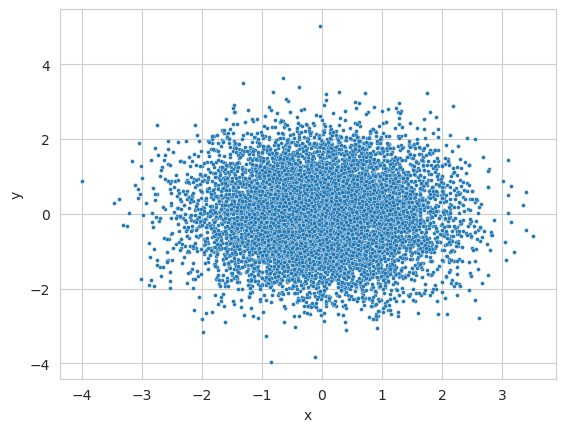

In [84]:
N = 10000
X_random = np.random.default_rng().normal(size=(N,2))
import seaborn as sns
import pandas as pd
df = pd.DataFrame(data=X_random, columns=['x','y'])
sns.scatterplot(data=df, x='x', y='y', s=8)

In [87]:
%%timeit
# avec une boucle for
norms = []
for x in X_random:
    norms.append(np.linalg.norm(x))

24.5 ms ± 1.81 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [89]:
# avec vectorisation
%timeit np.linalg.norm(X_random,axis=1)

184 μs ± 38 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


<a id="exercices"></a>
##### Exercices

__Exercice__.
Réécrire la fonction `euclidean_sim` avec NumPy pour tirer partie du broadcasting des fonctions vectorisées `np.linalg.norm` et `np.exp`.

In [ ]:
def euclidean_sim(a,b):
    pass
    # completer ici

similarites = euclidean_sim(x,X)

# --------- tests -------- #
try:
    assert similarites[1] == 2.417610491679649e-05, f'Erreur : la deuxième similarité trouvée doit être 2.417610491679649e-05, et non {similarites[1]}.'
    print('ok')
except AssertionError as e:
    print(e)   

similarites


__Exercice__.
Proposer une nouvelle implémentation des modules `cbp.algo.knn` et `cbp.similarity.measures` qui utilise NumPy.

Pour tester, on peut vérifier que comme au TP précédent, le code suivant affiche le nombre moyen de bonnes réponses sur Iris pour l'algorithme $k$-NN. 

In [ ]:
import csv
from cbp.algo import knn
from cbp.similarity.measures import euclidean_sim

outcomes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
(X_test, y_test) = ([], [])
with open('../data/iris.data') as f:
    reader = csv.reader(f, delimiter=',')
    for row in reader:
        X_test.append([float(v) for v in row[:4]])
        y_test.append(outcomes.index(row[4]))
(X_test, y_test) = (np.array(X_test), np.array(y_test))
    
nb_test = len(X_test)
(X, y) = (X_test, y_test)

accuracy = 0.
for i in range(nb_test):
    x = X_test[i]
    pred = knn.predict(x, X, y, euclidean_sim, n_neighbors=3)
    if pred == y_test[i]:
        accuracy += 1.
accuracy /= nb_test    

# --------- tests -------- #
try:
    assert accuracy ==0.96, 'Erreur : pour k=3, on doit trouver .96.'
except AssertionError as e:
    print(e)   
print(f"kNN accuracy = {accuracy}")